# V-Party Dataset — Full Exploration

This notebook loads the **full** V-Party datasets from `data/raw/vparty/` and performs a complete, reproducible overview: structure, coverage, missingness, duplicates, and basic distributions.

Run from the repository root so relative paths resolve.


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [19]:
# Paths
root = Path(".").resolve()

# If running from the notebooks/ directory, move up to the repo root
for _ in range(4):
    if (root / "data" / "raw" / "vparty").exists():
        break
    if root.parent == root:
        break
    root = root.parent

party_path = root / "data" / "raw" / "vparty" / "CPD_V-Party_CSV_v2" / "V-Dem-CPD-Party-V2.csv"
coder_path = root / "data" / "raw" / "vparty" / "Coder_Level_V-Party_CSV_v2" / "coder_level_ds_party_v2.csv"

pf_core_path = root / "data" / "external" / "partyfacts_core_parties.csv"
pf_external_path = root / "data" / "external" / "partyfacts_external_parties.csv"

# Fallback to repo-root copies if external paths are missing
if not pf_core_path.exists():
    alt = root / "partyfacts-core-parties.csv"
    if alt.exists():
        pf_core_path = alt

if not pf_external_path.exists():
    alt = root / "partyfacts-external-parties.csv"
    if alt.exists():
        pf_external_path = alt

if not party_path.exists():
    raise FileNotFoundError(f"Missing V-Party party-level CSV at {party_path}")

print("Party-level file:", party_path)
print("Coder-level file:", coder_path if coder_path.exists() else "(not found)")
print("PartyFacts core file:", pf_core_path if pf_core_path.exists() else "(not found)")
print("PartyFacts external file:", pf_external_path if pf_external_path.exists() else "(not found)")


Party-level file: /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/raw/vparty/CPD_V-Party_CSV_v2/V-Dem-CPD-Party-V2.csv
Coder-level file: /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/raw/vparty/Coder_Level_V-Party_CSV_v2/coder_level_ds_party_v2.csv
PartyFacts core file: /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/external/partyfacts_core_parties.csv
PartyFacts external file: /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/external/partyfacts_external_parties.csv


In [20]:
# Load the full party-level dataset
vparty = pd.read_csv(party_path, low_memory=False)

vparty.head()


,v2paenname,v2paorname,v2pashname,v2paid,pf_party_id,party_gaps,pf_url,country_name,histname,country_id,country_text_id,year,historical_date,codingstart,gapstart,gapend,codingend,project,COWcode,gap_index,v2xpa_antiplural,v2xpa_antiplural_codelow,v2xpa_antiplural_codehigh,v2xpa_popul,v2xpa_popul_codelow,v2xpa_popul_codehigh,v2paseatshare,v2panumbseat,v2patotalseat,v2pavote,v2paallian,v2panaallian,v2pavallian,v2panoallian,v2paelcont,v2paelcont_nr,v2pagovsup,v2papariah,v2papariah_codelow,v2papariah_codehigh,v2papariah_sd,v2papariah_osp,v2papariah_osp_codelow,v2papariah_osp_codehigh,v2papariah_osp_sd,v2papariah_ord,v2papariah_ord_codelow,v2papariah_ord_codehigh,v2papariah_mean,v2papariah_nr,v2paanteli,v2paanteli_codelow,v2paanteli_codehigh,v2paanteli_sd,v2paanteli_osp,v2paanteli_osp_codelow,v2paanteli_osp_codehigh,v2paanteli_osp_sd,v2paanteli_ord,v2paanteli_ord_codelow,v2paanteli_ord_codehigh,v2paanteli_mean,v2paanteli_nr,v2papeople,v2papeople_codelow,v2papeople_codehigh,v2papeople_sd,v2papeople_osp,v2papeople_osp_codelow,v2papeople_osp_codehigh,v2papeople_osp_sd,v2papeople_ord,v2papeople_ord_codelow,v2papeople_ord_codehigh,v2papeople_mean,v2papeople_nr,v2paopresp,v2paopresp_codelow,v2paopresp_codehigh,v2paopresp_sd,v2paopresp_osp,v2paopresp_osp_codelow,v2paopresp_osp_codehigh,v2paopresp_osp_sd,v2paopresp_ord,v2paopresp_ord_codelow,v2paopresp_ord_codehigh,v2paopresp_mean,v2paopresp_nr,v2paplur,v2paplur_codelow,v2paplur_codehigh,v2paplur_sd,v2paplur_osp,v2paplur_osp_codelow,v2paplur_osp_codehigh,v2paplur_osp_sd,v2paplur_ord,v2paplur_ord_codelow,v2paplur_ord_codehigh,...,v2paactcom_osp_sd,v2paactcom_ord,v2paactcom_ord_codelow,v2paactcom_ord_codehigh,v2paactcom_mean,v2paactcom_nr,v2pasoctie,v2pasoctie_codelow,v2pasoctie_codehigh,v2pasoctie_sd,v2pasoctie_osp,v2pasoctie_osp_codelow,v2pasoctie_osp_codehigh,v2pasoctie_osp_sd,v2pasoctie_ord,v2pasoctie_ord_codelow,v2pasoctie_ord_codehigh,v2pasoctie_mean,v2pasoctie_nr,v2panom,v2panom_codelow,v2panom_codehigh,v2panom_sd,v2panom_osp,v2panom_osp_codelow,v2panom_osp_codehigh,v2panom_osp_sd,v2panom_ord,v2panom_ord_codelow,v2panom_ord_codehigh,v2panom_mean,v2panom_nr,v2padisa,v2padisa_codelow,v2padisa_codehigh,v2padisa_sd,v2padisa_osp,v2padisa_osp_codelow,v2padisa_osp_codehigh,v2padisa_osp_sd,v2padisa_ord,v2padisa_ord_codelow,v2padisa_ord_codehigh,v2padisa_mean,v2padisa_nr,v2paind,v2paind_codelow,v2paind_codehigh,v2paind_sd,v2paind_osp,v2paind_osp_codelow,v2paind_osp_codehigh,v2paind_osp_sd,v2paind_ord,v2paind_ord_codelow,v2paind_ord_codehigh,v2paind_mean,v2paind_nr,v2pafunds_0,v2pafunds_nr,v2pafunds_1,v2pafunds_2,v2pafunds_3,v2pafunds_4,v2pafunds_5,v2pafunds_6,v2pafunds_7,v2pagroup_0,v2pagroup_nr,v2pagroup_1,v2pagroup_10,v2pagroup_11,v2pagroup_12,v2pagroup_13,v2pagroup_14,v2pagroup_2,v2pagroup_3,v2pagroup_4,v2pagroup_5,v2pagroup_6,v2pagroup_7,v2pagroup_8,v2pagroup_9,CHES_ID,ep_antielite_salience,ep_galtan,ep_corrupt_salience,ep_galtan_salience,ep_members_vs_leadership,ep_v6_lib_cons,ep_people_vs_elite,ep_v7_lib_cons_saliency,ep_type_populism,ep_type_populist_values,ep_v8_popul_rhetoric,ep_v9_popul_saliency,e_regiongeo,e_regionpol,e_regionpol_6C,GPS_ID
0,Party of the Democratic Revolution,NaN,PRD,216,216.0,NaN,https://partyfacts.herokuapp.com/data/partycod...,Mexico,United Mexican States,3,MEX,1991,1991-08-18,1940,NaN,NaN,2018,0,70.0,1,0.237,0.179,0.306,0.764,0.725,0.820,8.2,41.0,500.0,8.3,0.0,NaN,NaN,NaN,2.0,11.0,3.0,-0.826,-1.451,0.418,0.870,1.666,1.266,2.532,0.601,2.0,1.0,2.0,1.818,11.0,2.020,1.613,2.438,0.432,3.267,2.981,3.538,0.287,3.0,3.0,4.0,3.300,10.0,0.811,0.498,1.129,0.322,2.894,2.660,3.155,0.248,3.0,3.0,3.0,3.182,11.0,-0.846,-1.196,-0.459,0.388,1.557,1.271,1.889,0.319,1.0,1.0,2.0,1.700,10.0,0.985,0.577,1.268,0.349,3.449,3.291,3.645,0.174,4.0,3.0,4.0,...,0.202,2.0,2.0,2.0,1.636,11.0,0.274,-0.052,0.521,0.298,2.177,1.956,2.393,0.224,2.0,2.0,2.0,2.091,11.0,1.757,1.331,2.102,0.398,2.150,1.873,2.367,0.253,2.0,2.0,2.0,1.909,11.0,-0.654,-1.061,-0.230,0.422,2.049,1.707,2.425,0.357,2.0,2.0,2.0,

## PartyFacts datasets


In [21]:
# Load PartyFacts core + external mappings
if not pf_core_path.exists():
    raise FileNotFoundError(f"Missing PartyFacts core CSV at {pf_core_path}")
if not pf_external_path.exists():
    raise FileNotFoundError(f"Missing PartyFacts external CSV at {pf_external_path}")

partyfacts_core = pd.read_csv(pf_core_path, low_memory=False)
partyfacts_external = pd.read_csv(pf_external_path, low_memory=False)

print("PartyFacts core:", partyfacts_core.shape)
print("PartyFacts external:", partyfacts_external.shape)

partyfacts_core.head()


PartyFacts core: (7246, 17)
PartyFacts external: (45385, 17)


,country,partyfacts_id,technical,name_short,name,name_english,name_other,year_first,year_last,share,share_year,new,wikipedia,description,comment,created,modified
0,AFG,6641,NaN,SDP,Afğān Millat Gund,Afghan Social Democratic Party / Afghan Millat...,Pashto: افغان ټولنپال ولسواک ګوند‎ / افغان ملت...,1966,NaN,1.6,2010.0,NaN,https://en.wikipedia.org/wiki/Afghan_Millat_Party,4 of 249 seats in the 2010 Afghan parliamentar...,NaN,2019-02-02 19:46:04.587339+00:00,2025-11-08 15:22:23.545974+00:00
1,AFG,8280,NaN,EM,Etelaf-e Milli,National Coalition of Afghanistan,Persian: ائتلاف ملی,2010,NaN,NaN,NaN,NaN,https://en.wikipedia.org/wiki/National_Coaliti...,NaN,NaN,2020-03-31 10:27:18.711370+00:00,2021-07-14 13:29:31.458872+00:00
2,AFG,6642,NaN,IMA,Harakat-e Islami-yi Afghanistan,Islamic Movement of Afghanistan,Persian: حرکت اسلامی افغانستان‎,1978,NaN,1.6,2010.0,NaN,https://en.wikipedia.org/wiki/Islamic_Movement...,4 of 249 seats in the 2010 Afghan parliamentar...,NaN,2019-02-02 19:53:35.410246+00:00,2025-11-08 15:23:06.543712+00:00
3,AFG,8867,NaN,TJP,Hezb-e-Haq-wa-Adalat,Truth and Justice Party,Persian: حزب حق و عدالت,2011,NaN,NaN,NaN,NaN,https://en.wikipedia.org/wiki/Truth_and_Justic...,2003 Habiba Sorabi (Minister of Women's Affairs),NaN,2021-03-26 21:32:05.417782+00:00,2021-03-26 21:32:05.417820+00:00
4,AFG,6643,NaN,HI,Hezb-e Islami,Islamic Party,NaN,1975,1979.0,4.8,2005.0,NaN,https://en.wikipedia.org/wiki/Hezbi_Islami,12 of 249 seats in 2005 election,NaN,2019-02-02 20:04:51.631557+00:00,2022-01-08 14:47:42.619570+00:00


In [22]:
# Quick look at external dataset keys
if "dataset_key" in partyfacts_external.columns:
    partyfacts_external["dataset_key"].value_counts().head(20)


In [23]:
# Basic structure
print("Rows:", len(vparty))
print("Columns:", len(vparty.columns))
print("Year range:", vparty["year"].min(), "→", vparty["year"].max())

vparty.dtypes.head(20)


Rows: 11898
Columns: 384
Year range: 1900 → 2019


v2paenname          object
v2paorname          object
v2pashname          object
v2paid               int64
pf_party_id        float64
party_gaps          object
pf_url              object
country_name        object
histname            object
country_id           int64
country_text_id     object
year                 int64
historical_date     object
codingstart          int64
gapstart           float64
gapend             float64
codingend            int64
project              int64
COWcode            float64
gap_index            int64
dtype: object

In [24]:
# Memory usage by column (top 20)
mem = vparty.memory_usage(deep=True).sort_values(ascending=False)
mem.head(20)


pf_url                 1317525
histname               1040880
v2paenname             1025777
historical_date         797166
country_name            775051
v2pashname              723356
country_text_id         713880
v2paorname              578197
party_gaps              511072
v2panaallian            472356
v2pasalie_8              95184
v2pasalie_4              95184
v2pasalie_5              95184
v2pasalie_6              95184
v2pasalie_7              95184
v2palocoff               95184
v2pasalie_9              95184
v2pasalie_2              95184
v2palocoff_codelow       95184
v2palocoff_codehigh      95184
dtype: int64

In [25]:
# Missingness in key identifiers
key_cols = ["v2paid", "pf_party_id", "country_name", "country_id", "COWcode", "year", "v2pariglef"]
missing = vparty[key_cols].isna().mean().sort_values(ascending=False)
missing


v2pariglef      0.470247
COWcode         0.004118
pf_party_id     0.000084
v2paid          0.000000
country_name    0.000000
country_id      0.000000
year            0.000000
dtype: float64

In [26]:
# Duplicate check: (v2paid, year) should generally be unique
if {"v2paid", "year"}.issubset(vparty.columns):
    dup = vparty.duplicated(["v2paid", "year"]).sum()
    print("Duplicate (v2paid, year):", dup)


Duplicate (v2paid, year): 0


In [27]:
# Country coverage
if "country_name" in vparty.columns:
    country_counts = vparty["country_name"].value_counts().head(20)
    country_counts


In [28]:
# PartyFacts coverage
if "pf_party_id" in vparty.columns:
    pf_coverage = vparty["pf_party_id"].notna().mean()
    print(f"PartyFacts ID coverage: {pf_coverage:.2%}")


PartyFacts ID coverage: 99.99%


In [29]:
# Ideology distribution (v2pariglef)
if "v2pariglef" in vparty.columns:
    vparty["v2pariglef"].describe()


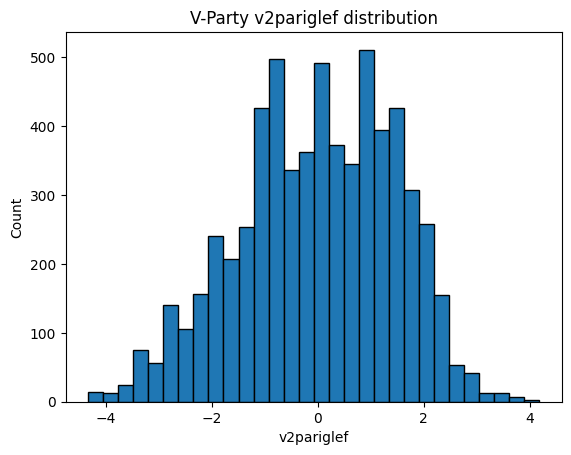

In [30]:
# Histogram of v2pariglef (ideology scale)
if "v2pariglef" in vparty.columns:
    vparty["v2pariglef"].dropna().plot(kind="hist", bins=30, edgecolor="black")
    plt.title("V-Party v2pariglef distribution")
    plt.xlabel("v2pariglef")
    plt.ylabel("Count")
    plt.show()


## Coder-level dataset (if present)


In [31]:
if coder_path.exists():
    coder = pd.read_csv(coder_path, low_memory=False)
    print("Coder-level rows:", len(coder))
    print("Coder-level columns:", len(coder.columns))
    coder.head()
else:
    coder = None


Coder-level rows: 30636
Coder-level columns: 155


In [32]:
if coder is not None:
    # Key coverage and duplicate checks
    key_cols = [c for c in ["v2paid", "coder_id", "historical_date"] if c in coder.columns]
    if key_cols:
        print("Missingness:")
        print(coder[key_cols].isna().mean().sort_values(ascending=False))

    if {"v2paid", "coder_id", "historical_date"}.issubset(coder.columns):
        dup = coder.duplicated(["v2paid", "coder_id", "historical_date"]).sum()
        print("Duplicate (v2paid, coder_id, historical_date):", dup)


Missingness:
v2paid             0.0
coder_id           0.0
historical_date    0.0
dtype: float64
Duplicate (v2paid, coder_id, historical_date): 0


## Quick cross-checks


In [33]:
# How many unique parties overlap between party-level and coder-level?
if coder is not None and "v2paid" in vparty.columns and "v2paid" in coder.columns:
    overlap = len(set(vparty["v2paid"].dropna()) & set(coder["v2paid"].dropna()))
    print("Unique v2paid overlap:", overlap)


Unique v2paid overlap: 1943
